# CS106 - Sesión 8 | Notebook 39: Proporciones y Contingencia (Chi-cuadrada) 📊

Cuando comparamos dos variables categóricas (ej. Sexo vs. Hospitalización), no buscamos promedios, sino **asociaciones**. La prueba de **Pearson $\chi^2$ (Chi-cuadrada)** nos permite saber si la distribución de una variable depende de la otra.

### ¿Qué estamos evaluando?
* **Hipótesis Nula ($H_0$):** Las variables son independientes (no hay relación).
* **Hipótesis Alternativa ($H_a$):** Existe una asociación significativa entre las variables.



### Consideración Técnica:
Si en alguna celda de tu tabla de contingencia hay menos de 5 casos, R aplicará automáticamente una corrección o sugerirá el uso del **Test Exacto de Fisher**.

## 1. Inspección Visual: Gráfico de Barras Apiladas
La mejor forma de "ver" una asociación es mediante proporciones. Si las barras de un grupo se ven muy distintas a las del otro, es probable que la prueba estadística confirme una asociación.

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.1     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.3     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Rows: 200 Columns: 9
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): nombre, sexo, diagnostico
dbl (5): id_paciente, edad, glucosa_mgdl, peso_kg, estatura_m
lgl (1): hospitalizado

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


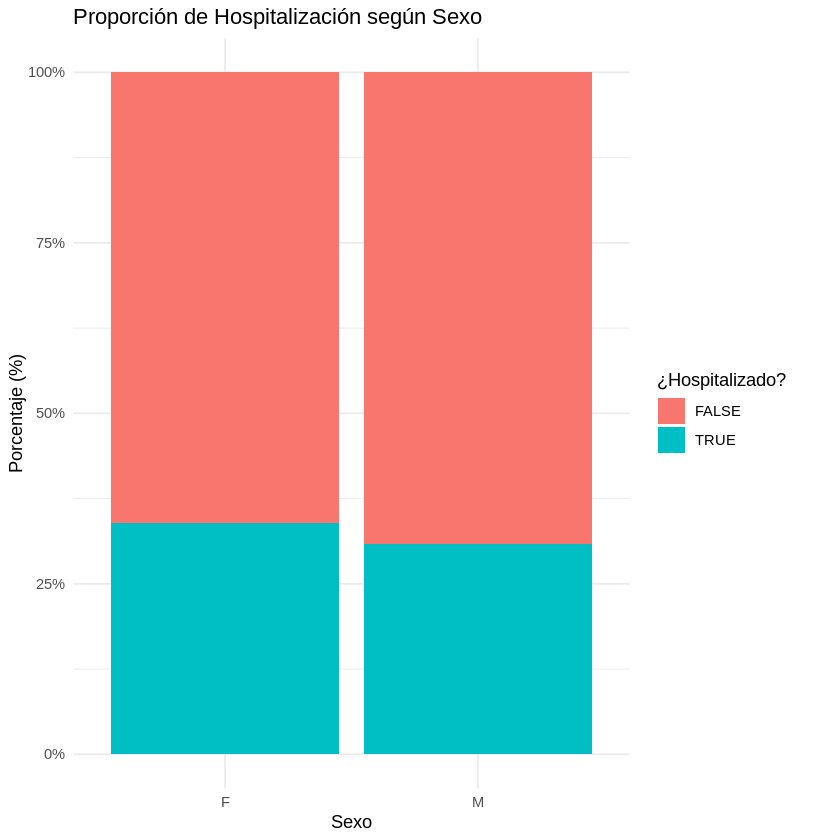

In [ ]:
library(tidyverse)
datos <- read_csv("cohorte_analisis.csv")

# Visualización de proporciones: Hospitalización por Sexo
ggplot(datos, aes(x = sexo, fill = hospitalizado)) +
  geom_bar(position = "fill") + # "fill" convierte las barras en porcentajes (0 a 1)
  scale_y_continuous(labels = scales::percent) +
  labs(title = "Proporción de Hospitalización según Sexo",
       x = "Sexo", y = "Porcentaje (%)", fill = "¿Hospitalizado?") +
  theme_minimal()

## 2. Frecuencias Observadas
Antes del test, debemos ver los números crudos. Una tabla de contingencia cruza las dos categorías para mostrar cuántos pacientes caen en cada combinación.

In [ ]:
# Creamos la tabla de contingencia
tabla_contingencia <- table(datos$sexo, datos$hospitalizado)
print(tabla_contingencia)

# Ejecutamos la prueba de Chi-cuadrada
resultado_chi <- chisq.test(tabla_contingencia)
print(resultado_chi)

   
    FALSE TRUE
  F    72   37
  M    63   28

	Pearson's Chi-squared test with Yates' continuity correction

data:  tabla_contingencia
X-squared = 0.10622, df = 1, p-value = 0.7445



## 3. Análisis Integral e Interpretación Clínica
Evaluaremos ahora si el **Diagnóstico** principal se asocia con el estado de **Hospitalización**.

**Tu misión:**
1. Ejecuta la celda para generar la tabla de frecuencias y el valor p.
2. Basado en la evidencia, completa las variables de respuesta.
3. Recuerda: Si **p < 0.05**, concluimos que el diagnóstico **SÍ** influye en la hospitalización.

In [ ]:
# --- 1. CÓDIGO INTEGRAL DE ANÁLISIS ---
# Cruzamos Diagnóstico vs Hospitalización
tabla_reto <- table(datos$diagnostico, datos$hospitalizado)
test_reto <- chisq.test(tabla_reto)

print(tabla_reto)
print(test_reto)

# --- 2. SECCIÓN DE RESPUESTAS (RELLENA LOS VALORES) ---

# r1: Valor p observado (ejemplo: 0.0001)
r1_p_valor <- 0.0000

# r2: ¿Existe una asociación significativa? (Escribe TRUE o FALSE)
r2_existe_asociacion <- ""

# r3: Según la tabla, ¿qué diagnóstico parece tener más hospitalizados ("SI")?
# Escribe el nombre exacto: "Diabetes", "Hipertension" o "Sano"
r3_diagnostico_riesgo <- ""

# --- 3. CONSTRUCCIÓN DEL DATA FRAME ---
df_respuesta <- data.frame(
  pregunta = c("p_valor", "asociacion", "riesgo_alto"),
  respuesta = c(as.character(r1_p_valor), r2_existe_asociacion, r3_diagnostico_riesgo)
)
print(df_respuesta)

              
               FALSE TRUE
  Diabetes        29   20
  Hipertensión    39   15
  Obesidad        31   20
  Sano            36   10

	Pearson's Chi-squared test

data:  tabla_reto
X-squared = 5.5703, df = 3, p-value = 0.1345

     pregunta respuesta
1     p_valor         0
2  asociacion          
3 riesgo_alto          


In [ ]:
# Ejecuta para guardar tu avance
source("utilidades.r")
guardar_39(df_respuesta)